# End-to-End

In [20]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import re
from pathlib import Path

matplotlib.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'axes.labelsize': 16,

    'xtick.labelsize': 14,
    'ytick.labelsize': 13,
})

RESULTS_ROOT = Path.home() / "power/GPGPU/coSched/results"
SYSTEMS = ["H100","A100","V100"]
SYSTEMS = ["H100"]
WORKLOAD = "mix"

POLICY_FILES = {
    "Sequential": "run_cosched_sequential_bestGPU.txt",
    "Marble":     "run_cosched_marble.txt",
    "EcoPack":    "EcoPack_cmab_run_10.txt",
    "Oracle":     "solver_execution_run.txt",
}

def parse_energy_makespan(filepath: Path):
    """Extract Total GPU energy (kJ) and Total makespan (s) from a result file."""
    text = filepath.read_text()
    energy_m = re.search(r"Total GPU energy:\s+([0-9.]+)\s+J", text)
    makespan_m = re.search(r"Total makespan:\s+([0-9.]+)s", text)
    if not energy_m or not makespan_m:
        return None, None
    return float(energy_m.group(1)) / 1000.0, float(makespan_m.group(1))

# Collect data per system
system_data = {}
for sys_name in SYSTEMS:
    sys_dir = RESULTS_ROOT / sys_name / WORKLOAD
    if not sys_dir.exists():
        continue
    policies_found = {}
    for policy, fname in POLICY_FILES.items():
        fpath = sys_dir / fname
        if not fpath.exists():
            continue
        energy_kj, makespan_s = parse_energy_makespan(fpath)
        if energy_kj is not None:
            policies_found[policy] = {"energy_kj": energy_kj, "makespan_s": makespan_s}
    if policies_found:
        system_data[sys_name] = policies_found


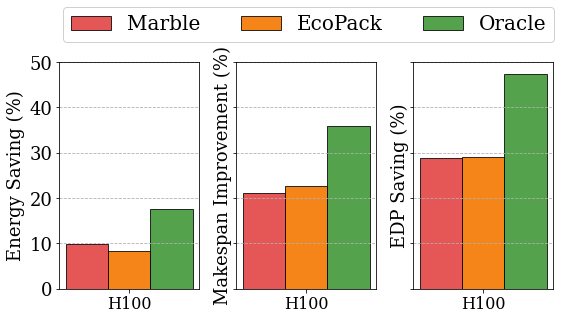

In [21]:

# --- Normalized Savings / Improvement (grouped bars: systems × policies) ---
# Uses `system_data` from the cell above.

policies_order = ["Marble", "EcoPack", "Oracle"]  # exclude Sequential (baseline)
colors_policy = {
    "Marble":  "#E45756",
    "EcoPack":  "#F58518",
    "Oracle":  "#54A24B",
}

systems = list(system_data.keys())
n_systems = len(systems)
n_policies = len(policies_order)

# Build matrices: rows = systems, cols = policies
energy_saving = np.full((n_systems, n_policies), np.nan)
makespan_impr = np.full((n_systems, n_policies), np.nan)
edp_saving    = np.full((n_systems, n_policies), np.nan)

for i, sys_name in enumerate(systems):
    seq = system_data[sys_name]["Sequential"]
    seq_energy = seq["energy_kj"]
    seq_makespan = seq["makespan_s"]
    seq_edp = seq_energy * seq_makespan
    for j, pol in enumerate(policies_order):
        if pol not in system_data[sys_name]:
            continue
        p = system_data[sys_name][pol]
        p_energy = p["energy_kj"]
        p_makespan = p["makespan_s"]
        p_edp = p_energy * p_makespan
        energy_saving[i, j] = (seq_energy - p_energy) / seq_energy * 100
        makespan_impr[i, j] = (seq_makespan - p_makespan) / seq_makespan * 100
        edp_saving[i, j]    = (seq_edp - p_edp) / seq_edp * 100

# Compute shared y-axis limits across all three metrics
all_vals = np.concatenate([energy_saving.ravel(), makespan_impr.ravel(), edp_saving.ravel()])
all_vals = all_vals[~np.isnan(all_vals)]
shared_ymin = np.floor(all_vals.min() / 5) * 5 - 5
shared_ymax = np.ceil(all_vals.max() / 5) * 5

# Plotting: 1 row, 3 columns, shared y-axis
fig, axes = plt.subplots(1, 3, figsize=(8, 4), sharey=True)

bar_width = 0.22
x = np.arange(n_systems)

datasets = [
    (energy_saving, "Energy Saving (%)"),
    (makespan_impr, "Makespan Improvement (%)"),
    (edp_saving,    "EDP Saving (%)")
]

for ax, (data, ylabel) in zip(axes, datasets):
    for j, pol in enumerate(policies_order):
        offset = (j - (n_policies - 1) / 2) * bar_width
        vals = data[:, j]
        ax.bar(x + offset, vals, bar_width, label=pol,
               color=colors_policy[pol], edgecolor='black', linewidth=0.8)

    ax.set_xticks(x)
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_xticklabels(systems)
    ax.set_ylabel(ylabel,fontsize=18)
    ax.set_ylim(shared_ymin, shared_ymax)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.grid(axis='y', linestyle='--', alpha=1)

# Single shared legend on top
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=n_policies,
           fontsize=20, bbox_to_anchor=(0.55, 1.15), framealpha=0.9)

plt.tight_layout()
plt.savefig('../fig/e2e_savings_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [22]:
import pandas as pd
from pathlib import Path
import re

DATA_ROOT = Path.home() / "power/GPGPU/coSched/data"
RESULTS_ROOT = Path.home() / "power/GPGPU/coSched/results"
# SYSTEMS = ["H100", "A100", "V100"]

def parse_perf_metrics_optimal(data_root, sys_name):
    """Find the optimal GPU count (lowest runtime) for each app from perf_metrics.txt."""
    path = data_root / sys_name / "perf_metrics.txt"
    if not path.exists():
        return {}
    optimal = {}
    current_app = None
    best_rt, best_gpu = None, None
    section_re = re.compile(r'^===== .*?/([^/ ]+) =====$')
    for line in path.read_text().splitlines():
        line_s = line.strip()
        m = section_re.match(line_s)
        if m:
            if current_app and best_gpu is not None:
                optimal[current_app] = best_gpu
            current_app = m.group(1)
            best_rt, best_gpu = None, None
            continue
        if current_app is None or line_s.startswith('cap=') or line_s.startswith('gpu_count'):
            continue
        parts = line_s.split()
        if len(parts) >= 2:
            try:
                gpu_count = int(parts[0])
                runtime = float(parts[1])
                if best_rt is None or runtime < best_rt:
                    best_rt = runtime
                    best_gpu = gpu_count
            except ValueError:
                pass
    if current_app and best_gpu is not None:
        optimal[current_app] = best_gpu
    return optimal

def parse_ecopack_gpu_counts(results_root, sys_name, ecopack_fname):
    """Parse EcoPack run file for selected GPU counts per app."""
    path = results_root / sys_name / "mix" / ecopack_fname
    if not path.exists():
        return {}
    lines = path.read_text().splitlines()
    start = next((i for i, l in enumerate(lines) if l.strip() == "Online co-schedule summary:"), None)
    if start is None:
        return {}
    gpu_counts = {}
    for line in lines[start + 3:]:
        s = line.strip()
        if not s or set(s) == {"-"}:
            break
        m = re.match(r"^\s*(\S+)\s+(\d+)\s+\[.*?\]\s+\d+\s+[0-9.]+\s*$", line)
        if m:
            gpu_counts[m.group(1)] = int(m.group(2))
    return gpu_counts

# Build table
rows = []
for sys_name in SYSTEMS:
    optimal = parse_perf_metrics_optimal(DATA_ROOT, sys_name)
    selected = parse_ecopack_gpu_counts(RESULTS_ROOT, sys_name, POLICY_FILES["EcoPack"])
    apps = sorted(set(optimal.keys()) & set(selected.keys()))
    for app in apps:
        rows.append({
            "System": sys_name,
            "Application": app,
            "Optimal GPUs": optimal[app],
            "EcoPack GPUs": selected[app],
            "Match": "✓" if optimal[app] == selected[app] else "✗",
        })

df = pd.DataFrame(rows)

# Pivot for a compact view: rows=apps, columns=(system, metric)
for sys_name in SYSTEMS:
    sdf = df[df["System"] == sys_name][["Application", "Optimal GPUs", "EcoPack GPUs", "Match"]]
    sdf = sdf.set_index("Application")
    print(f"\n{'='*60}")
    print(f"  {sys_name}: Optimal vs EcoPack GPU Count")
    print(f"{'='*60}")
    print(sdf.to_string())
    n_match = (sdf["Match"] == "✓").sum()
    print(f"\nMatch rate: {n_match}/{len(sdf)} ({n_match/len(sdf)*100:.0f}%)")



  H100: Optimal vs EcoPack GPU Count
                                Optimal GPUs  EcoPack GPUs Match
Application                                                     
MonteCarloMultiGPU                         1             1     ✓
bert                                       4             4     ✓
cloverleaf                                 4             4     ✓
conjugateGradientMultiDeviceCG             4             4     ✓
gpt2                                       3             2     ✗
lbm                                        4             4     ✓
minisweep                                  4             4     ✓
miniweather                                1             1     ✓
pot3d                                      4             3     ✗
resnet101                                  4             4     ✓
resnet152                                  3             3     ✓
resnet50                                   4             3     ✗
simpleP2P                                  2        

# Per-job performance

In [23]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_ROOT = Path.home() / "power/GPGPU/data"
RESULTS_ROOT = Path.home() / "power/GPGPU/coSched/results"
# SYSTEMS = ["H100"]
# SYSTEMS=["H100","A100","V100"]



def parse_sequential_bestgpu_runtime(path: Path):
    """Parse run_cosched_sequential_bestGPU.txt summary table for baseline runtimes."""
    lines = path.read_text().splitlines()
    # Find the summary section
    start = next((i for i, line in enumerate(lines) if line.strip() == "Sequential summary:"), None)
    if start is None:
        return {}, {}
    runtimes = {}
    gpu_counts = {}
    # Summary format: App  #GPUs  GPU IDs  Runtime (s)
    for line in lines[start + 3:]:
        s = line.strip()
        if not s or set(s) == {"-"}:
            break
        # Match: app_name  gpu_count  [gpu_ids]  runtime
        m = re.match(r"^\s*(\S+)\s+(\d+)\s+\[.*?\]\s+([0-9.]+)\s*$", line)
        if m:
            app = m.group(1)
            gpu_counts[app] = int(m.group(2))
            runtimes[app] = float(m.group(3))
    return runtimes, gpu_counts

def parse_online_runtime(path: Path):
    """Parse EcoPack online co-schedule summary for runtimes and GPU counts."""
    lines = path.read_text().splitlines()
    start = next((i for i, line in enumerate(lines) if line.strip() == "Online co-schedule summary:"), None)
    if start is None:
        return {}, {}
    runtimes = {}
    gpu_counts = {}
    # Summary format: App  #GPUs  GPU IDs  NUMA  Runtime (s)
    for line in lines[start + 3:]:
        s = line.strip()
        if not s or set(s) == {"-"}:
            break
        m = re.match(r"^\s*(\S+)\s+(\d+)\s+\[.*?\]\s+\d+\s+([0-9.]+)\s*$", line)
        if m:
            app = m.group(1)
            gpu_counts[app] = int(m.group(2))
            runtimes[app] = float(m.group(3))
    return runtimes, gpu_counts

all_dfs = {}
for sys_name in SYSTEMS:
    baseline_path = RESULTS_ROOT / sys_name / "mix" / POLICY_FILES["Sequential"]
    online_path = RESULTS_ROOT / sys_name / "mix" / POLICY_FILES["EcoPack"]
    if not baseline_path.exists() or not online_path.exists():
        print(f"[{sys_name}] Skipping — missing {POLICY_FILES['Sequential']} or {POLICY_FILES['EcoPack']}")
        continue

    baseline_rt, baseline_gpu = parse_sequential_bestgpu_runtime(baseline_path)
    online_rt, online_gpu = parse_online_runtime(online_path)
    if not online_rt:
        print(f"[{sys_name}] Skipping — no online summary found")
        continue

    apps = sorted(set(baseline_rt) & set(online_rt))
    rows = []
    for app in apps:
        base = baseline_rt[app]
        online = online_rt[app]
        rows.append({
            "app": app,
            "system": sys_name,
            "baseline_gpu": baseline_gpu[app],
            "ecopack_gpu": online_gpu[app],
            "baseline_runtime_s": base,
            "online_runtime_s": online,
            "runtime_delta_s": online - base,
            "runtime_increase_pct": (online - base) / base * 100.0,
            "performance_loss_pct": (1.0 - (base / online)) * 100.0,
        })

    df = pd.DataFrame(rows)
    all_dfs[sys_name] = df

/home/ac.zzheng/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:54: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations. 


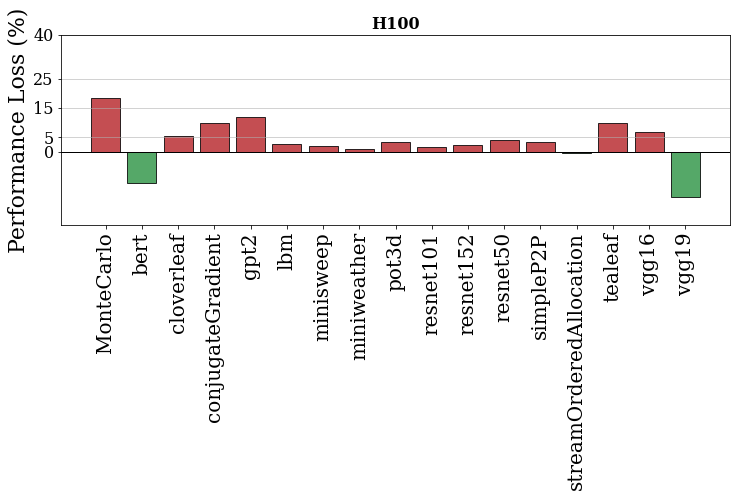

In [24]:
import matplotlib.pyplot as plt

# Shorten long app names
name_map = {
    'MonteCarloMultiGPU': 'MonteCarlo',
    'conjugateGradientMultiDeviceCG': 'conjugateGradient',
    'streamOrderedAllocationP2P': 'streamOrderedAllocation',
}

# Compute shared y-axis limits across all systems
all_y = []
for sys_name, df in all_dfs.items():
    all_y.extend(df["performance_loss_pct"].values)
all_y = np.array(all_y)
shared_ymin = np.floor(all_y.min() / 5) * 5 - 5
shared_ymax = np.ceil(all_y.max() / 5) * 5 + 5

n_sys = len(all_dfs)
fig, axes = plt.subplots(n_sys, 1, figsize=(12, 3.5 * n_sys), sharex=False)
if n_sys == 1:
    axes = [axes]

for idx, (sys_name, df) in enumerate(all_dfs.items()):
    ax = axes[idx]
    plot_df = df.reset_index(drop=True)
    x = np.arange(len(plot_df))
    y = plot_df["performance_loss_pct"].values

    colors = ["#C44E52" if v > 0 else "#55A868" for v in y]
    ax.bar(x, y, color=colors, edgecolor="black", linewidth=0.8)
    ax.axhline(0, color="black", linewidth=1)
    # Replace per-axis ylabel with a single shared one
    if idx == n_sys // 2:
        ax.set_ylabel("Performance Loss (%)",fontsize=22)
    else:
        ax.set_ylabel("")

    ax.set_title(sys_name, fontsize=16, fontweight='bold')
    ax.set_ylim(shared_ymin, shared_ymax)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_yticks([0, 5, 15, 25, 40])
    ax.grid(axis='y', linestyle='-',alpha=0.7)

    # Shortened app labels
    app_labels = [name_map.get(a, a) for a in plot_df["app"]]
    ax.set_xticks(x)

    # Only show x labels on the bottom plot
    if idx == n_sys - 1:
        ax.set_xticklabels(app_labels, rotation=90, ha='center', fontsize=20)
    else:
        ax.set_xticklabels([])

plt.tight_layout()
plt.savefig('../fig/perf_loss_combined.png', dpi=300, bbox_inches='tight')
plt.show()

# Mixed Workloads

In [14]:

import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import re
from pathlib import Path

matplotlib.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 13,
})

RESULTS_ROOT = Path.home() / "power/GPGPU/coSched/results"
SYSTEMS = ["H100", "A100","V100"]
SYSTEMS = ["A100","V100"]
WORKLOADS = ["low", "med", "high"]

POLICY_FILES = {
    "Seq-bestGPU": "run_cosched_sequential_bestGPU.txt",
    "Seq-maxGPU":  "run_cosched_sequential.txt",
    "Marble":      "run_cosched_marble.txt",
    "EcoPack":     "EcoPack_cmab_run_10.txt",
    "Oracle":      "solver_execution_run.txt",
}

COLORS = {
    "Marble":      "#E45756",
    "EcoPack":     "#F58518",
    "Oracle":      "#54A24B",
}

def parse_energy_makespan(filepath: Path):
    """Extract Total GPU energy (kJ) and Total makespan (s) from a result file."""
    if not filepath.exists() or filepath.stat().st_size == 0:
        return None, None
    text = filepath.read_text()
    energy_m = re.search(r"Total GPU energy:\s+([0-9.]+)\s+J", text)
    makespan_m = re.search(r"Total makespan:\s+([0-9.]+)s", text)
    if not energy_m or not makespan_m:
        return None, None
    return float(energy_m.group(1)) / 1000.0, float(makespan_m.group(1))

# ── Collect data: mix_data[sys][wl][policy] = {energy_kj, makespan_s} ──
mix_data = {}
for sys_name in SYSTEMS:
    for wl in WORKLOADS:
        wl_dir = RESULTS_ROOT / sys_name / wl
        if not wl_dir.exists():
            continue
        policies_found = {}
        for policy, fname in POLICY_FILES.items():
            energy_kj, makespan_s = parse_energy_makespan(wl_dir / fname)
            if energy_kj is not None:
                policies_found[policy] = {"energy_kj": energy_kj, "makespan_s": makespan_s}
        if policies_found:
            mix_data.setdefault(sys_name, {})[wl] = policies_found

# Build list of valid (sys, wl) combos that have at least Seq-bestGPU
combos = []
for sys_name in SYSTEMS:
    if sys_name not in mix_data:
        continue
    for wl in WORKLOADS:
        if wl in mix_data[sys_name] and "Seq-bestGPU" in mix_data[sys_name][wl]:
            combos.append((sys_name, wl))

n_combos = len(combos)

# Show what we found
for sys_name, wl in combos:
    pols = list(mix_data[sys_name][wl].keys())
    print(f"{sys_name}/{wl}: {pols}")
print(f"\nTotal combos: {n_combos}")


A100/low: ['Seq-bestGPU', 'Seq-maxGPU', 'Marble', 'Oracle']
A100/med: ['Seq-bestGPU', 'Seq-maxGPU', 'Marble', 'Oracle']
A100/high: ['Seq-bestGPU', 'Seq-maxGPU', 'Marble', 'Oracle']
V100/low: ['Seq-bestGPU', 'Seq-maxGPU', 'Marble', 'Oracle']
V100/med: ['Seq-bestGPU', 'Seq-maxGPU', 'Marble', 'Oracle']
V100/high: ['Seq-bestGPU', 'Seq-maxGPU', 'Marble', 'Oracle']

Total combos: 6


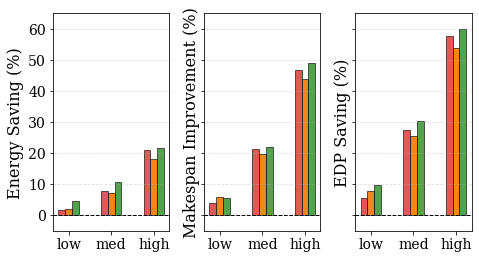

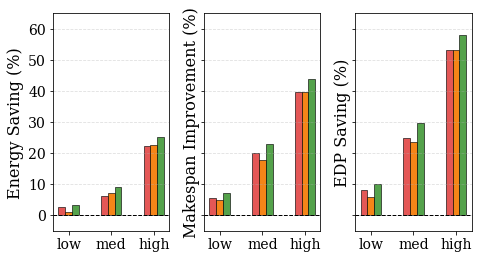

In [6]:

# ── Figure 2: Savings (%) vs Seq-bestGPU ──
# One figure per system, 3 columns: Energy Saving, Makespan Improvement, EDP Saving
# X-axis = workload classes (low, med, high), grouped bars = policies

saving_policies = ["Marble", "EcoPack", "Oracle"]
n_sp = len(saving_policies)

for sys_name in SYSTEMS:
    if sys_name not in mix_data:
        continue

    # Get available workloads for this system
    sys_wls = [wl for wl in WORKLOADS if wl in mix_data[sys_name] and "Seq-bestGPU" in mix_data[sys_name][wl]]
    if not sys_wls:
        continue

    n_wl = len(sys_wls)

    # Compute savings matrices: rows = workloads, cols = policies
    energy_sav = np.full((n_wl, n_sp), np.nan)
    makespan_sav = np.full((n_wl, n_sp), np.nan)
    edp_sav = np.full((n_wl, n_sp), np.nan)

    for i, wl in enumerate(sys_wls):
        pdata = mix_data[sys_name][wl]
        seq = pdata["Seq-bestGPU"]
        se, sm = seq["energy_kj"], seq["makespan_s"]
        sedp = se * sm
        for j, pol in enumerate(saving_policies):
            if pol not in pdata:
                continue
            p = pdata[pol]
            pe, pm = p["energy_kj"], p["makespan_s"]
            energy_sav[i, j] = (se - pe) / se * 100
            makespan_sav[i, j] = (sm - pm) / sm * 100
            edp_sav[i, j] = (sedp - pe * pm) / sedp * 100

    # Shared y-axis across all 3 columns for this system
    all_sav = np.concatenate([energy_sav.ravel(), makespan_sav.ravel(), edp_sav.ravel()])
    all_sav = all_sav[~np.isnan(all_sav)]
    symin = np.floor(all_sav.min() / 5) * 5 - 5
    symax = np.ceil(all_sav.max() / 5) * 5 + 5

    fig, axes = plt.subplots(1, 3, figsize=(2.5 * n_wl, 4), sharey=True)
    fig.subplots_adjust(wspace=0.3)
    bar_w = 0.16
    x = np.arange(n_wl)

    for idx, (ax, (data, ylabel)) in enumerate(zip(axes, [
        (energy_sav, "Energy Saving (%)"),
        (makespan_sav, "Makespan Improvement (%)"),
        (edp_sav, "EDP Saving (%)")
    ])):
        for j, pol in enumerate(saving_policies):
            offset = (j - (n_sp - 1) / 2) * bar_w
            vals = data[:, j]
            ax.bar(x + offset, vals, bar_w, label=pol,
                   color=COLORS[pol], edgecolor='black', linewidth=0.6)

        ax.set_xticks(x)
        ax.tick_params(axis='y', labelsize=14)
        ax.set_xticklabels(sys_wls)
        ax.set_ylabel(ylabel)
        ax.set_ylim(symin, symax)
        ax.axhline(0, color='black', linewidth=1, linestyle='--')
        ax.grid(axis='y', linestyle='--', alpha=0.4)

    # Single shared legend on top of all 3 subplots
    handles, labels = axes[0].get_legend_handles_labels()
    # fig.legend(handles, labels, loc='upper center', ncol=n_sp,
    #            fontsize=16, bbox_to_anchor=(0.5, 1.08), framealpha=0.9)

    # axes[0].set_title(f'{sys_name}', fontsize=18, fontweight='bold')
    plt.savefig(f'../fig/mixed_savings_{sys_name}.png', dpi=300, bbox_inches='tight')
    plt.show()


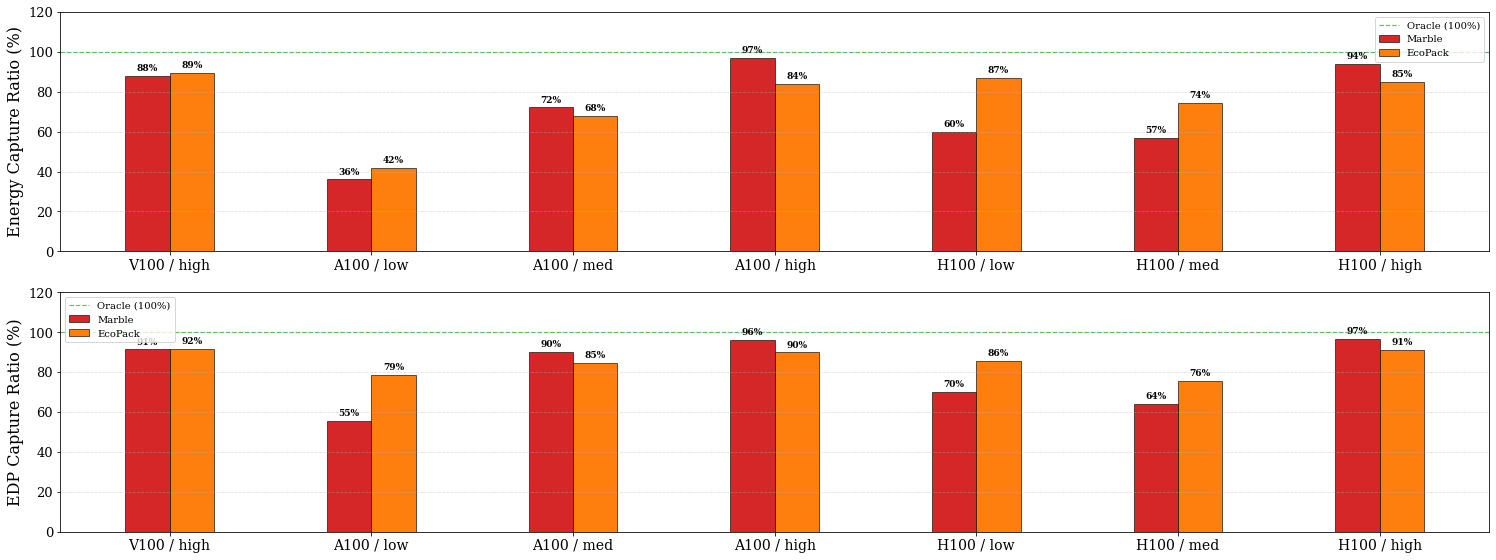

In [17]:

# ── Figure 3: Capture Ratio ──
# Capture = (Seq-bestGPU - Policy) / (Seq-bestGPU - Oracle)
# For Energy and EDP, only Marble & EcoPack (Oracle = 100% by definition)

capture_policies = ["Marble", "EcoPack"]
n_cp = len(capture_policies)

# Only combos that have Oracle
cap_combos = [(s, w) for s, w in combos
              if "Oracle" in mix_data[s][w]]
n_cc = len(cap_combos)

if n_cc > 0:
    energy_cap = np.full((n_cc, n_cp), np.nan)
    edp_cap    = np.full((n_cc, n_cp), np.nan)

    for i, (sys_name, wl) in enumerate(cap_combos):
        pdata = mix_data[sys_name][wl]
        seq = pdata["Seq-bestGPU"]
        orc = pdata["Oracle"]
        se, sm = seq["energy_kj"], seq["makespan_s"]
        oe, om = orc["energy_kj"], orc["makespan_s"]

        e_avail = se - oe
        edp_avail = se * sm - oe * om

        for j, pol in enumerate(capture_policies):
            if pol not in pdata:
                continue
            p = pdata[pol]
            pe, pm = p["energy_kj"], p["makespan_s"]
            if e_avail != 0:
                energy_cap[i, j] = (se - pe) / e_avail * 100
            if edp_avail != 0:
                edp_cap[i, j] = (se * sm - pe * pm) / edp_avail * 100

    fig, axes = plt.subplots(2, 1, figsize=(max(6, 3 * n_cc), 8))
    bar_w = 0.22
    x = np.arange(n_cc)

    for ax, (data, ylabel) in zip(axes, [
        (energy_cap, "Energy Capture Ratio (%)"),
        (edp_cap,    "EDP Capture Ratio (%)")
    ]):
        for j, pol in enumerate(capture_policies):
            offset = (j - (n_cp - 1) / 2) * bar_w
            vals = data[:, j]
            bars = ax.bar(x + offset, vals, bar_w, label=pol,
                          color=COLORS[pol], edgecolor='black', linewidth=0.6)
            for k, v in enumerate(vals):
                if not np.isnan(v):
                    ax.text(x[k] + offset, v + 1.5, f'{v:.0f}%',
                            ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.axhline(100, color='#2ca02c', linewidth=1.2, linestyle='--',
                   alpha=0.7, label='Oracle (100%)')
        ax.set_xticks(x)
        ax.set_xticklabels([f"{s} / {w}" for s, w in cap_combos])
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, max(np.nanmax(data), 100) * 1.2)
        ax.legend(loc='best', fontsize=10)
        ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig('./fig/mixed_capture_ratio.png', dpi=300)
    plt.show()
else:
    print("No combos with Oracle data found — skipping capture ratio plot.")
